In [91]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

In [92]:
mnistDataset = fetch_openml("mnist_784", as_frame=False)
X, y = mnistDataset.data, mnistDataset.target
X, y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object))

In [ ]:
compressedPipeline = Pipeline(
    [
        ("92% variance", PCA(n_components=0.92, svd_solver="full")),
        ("2D compression", TSNE(n_components=2, max_iter=5_000, random_state=67))
    ]
)

In [94]:
xCompressed = compressedPipeline.fit_transform(X)

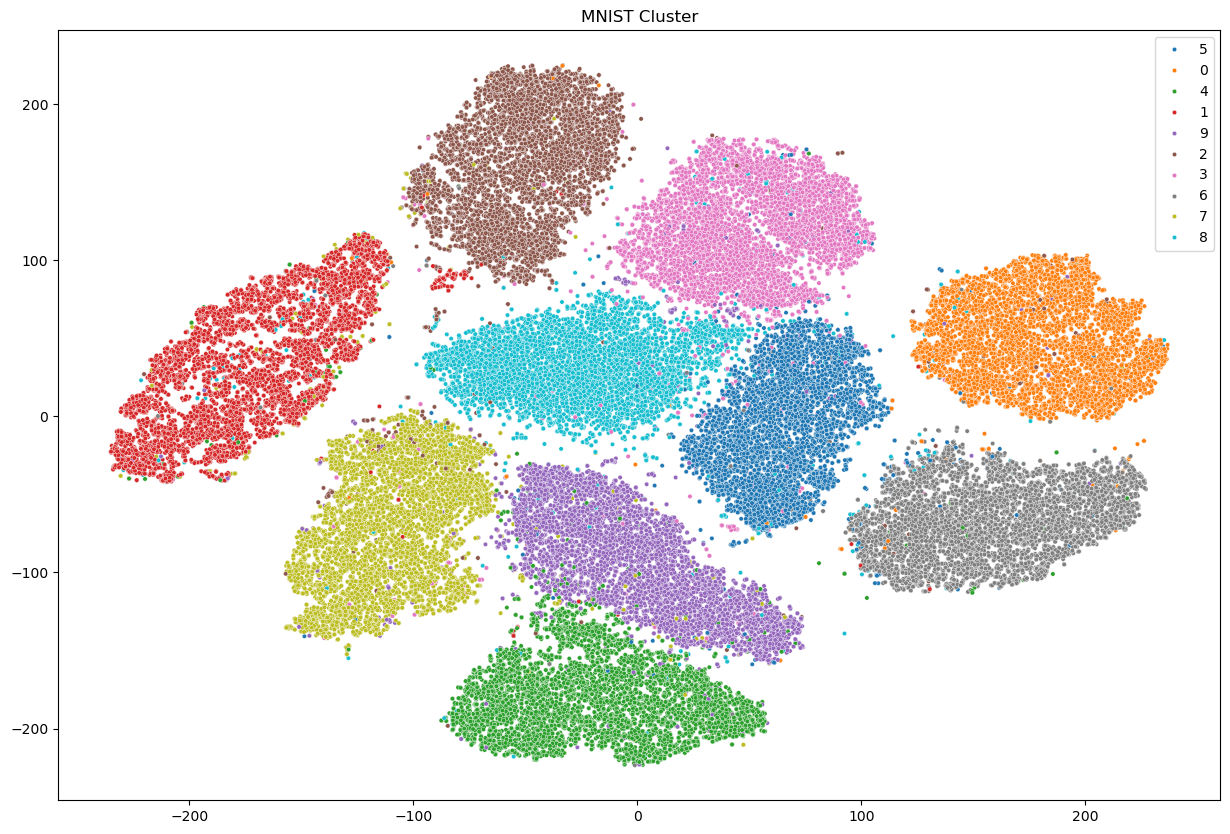

In [95]:
plt.figure(figsize=(15,10))
sns.scatterplot(x=xCompressed[:,0], y=xCompressed[:,1], hue=y, s=10, palette="tab10", alpha=1)
plt.title("MNIST Cluster")
plt.show()

In [96]:
standalonPCA = PCA(n_components=0.99, svd_solver="full")
xPCA = standalonPCA.fit_transform(X)
standalonPCA.n_components_

np.int64(331)

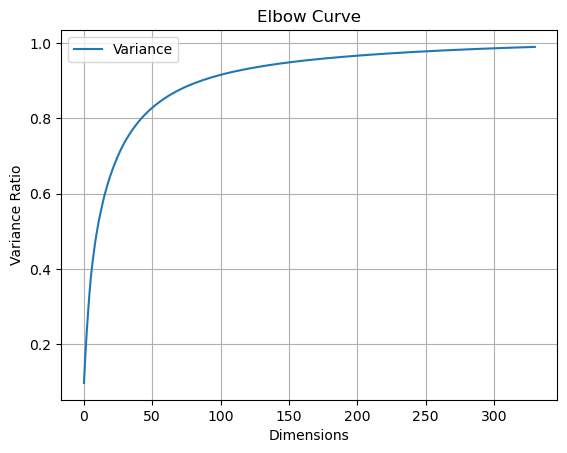

In [97]:
sns.lineplot(np.cumsum(standalonPCA.explained_variance_ratio_), label="Variance")
plt.ylabel("Variance Ratio")
plt.xlabel("Dimensions")
plt.title("Elbow Curve")
plt.legend(loc="best")
plt.grid()
plt.show()